In [1]:
"""
====================================================
2D fluorescence-decay correlation (2D-FDC / 2D-FLCS)
====================================================

Two-dimensional fluorescence lifetime correlation spectroscopy (2D-FLCS)
measures the **joint distribution of the two micro-times** of photon pairs
separated by a chosen macro-time lag. Off-diagonal weight in that matrix means
the emitter changed its decay between the two photons, so the lag dependence of
the coupling measures the interconversion rate directly -- no filter patterns to
know in advance, no second detector.

This example simulates the experiment with :class:`tttrlib.SimEngine` (one
immobile molecule, two lifetime states exchanging at a known rate) and builds
the matrices with the 2D-FDC photon pass (:func:`tttrlib.fdc_scan_log` and
:func:`tttrlib.fdc_scan_two_axes`), which implements the original author's
algorithm tick for tick:

- K. Ishii and T. Tahara, "Two-Dimensional Fluorescence Lifetime Correlation
  Spectroscopy. 1. Principle", J. Phys. Chem. B 117(39), 11414-11422 (2013),
  doi:10.1021/jp406861u
- K. Ishii and T. Tahara, "Two-Dimensional Fluorescence Lifetime Correlation
  Spectroscopy. 2. Application", J. Phys. Chem. B 117(39), 11423-11432 (2013),
  doi:10.1021/jp406864e
- T. Kondo, J. B. Gordon, A. Pinnola, L. Dall'osto, R. Bassi and
  G. S. Schlau-Cohen, "Microsecond and millisecond dynamics in the photosynthetic
  protein LHCSR1 observed by single-molecule correlation spectroscopy",
  Proc. Natl. Acad. Sci. USA 116(23), 11247-11252 (2019),
  doi:10.1073/pnas.1821207116 -- the application the kernels' reference
  implementation (``TK_Create2DFDC_04.m``, T. Kondo, Schlau-Cohen lab, MIT) was
  written for.

The lifetimes are 1.5 ns and 3.5 ns and the exchange is 10 /s both ways, so the
relaxation time is 1/(k01+k10) = 50 ms. The statistic plotted is the total
variation between the pair distribution and the product of its own marginals:
zero once the state has fully relaxed between the two photons, positive while
the pairs remember their shared state.
"""

'\n====================================================\n2D fluorescence-decay correlation (2D-FDC / 2D-FLCS)\n====================================================\n\nTwo-dimensional fluorescence lifetime correlation spectroscopy (2D-FLCS)\nmeasures the **joint distribution of the two micro-times** of photon pairs\nseparated by a chosen macro-time lag. Off-diagonal weight in that matrix means\nthe emitter changed its decay between the two photons, so the lag dependence of\nthe coupling measures the interconversion rate directly -- no filter patterns to\nknow in advance, no second detector.\n\nThis example simulates the experiment with :class:`tttrlib.SimEngine` (one\nimmobile molecule, two lifetime states exchanging at a known rate) and builds\nthe matrices with the 2D-FDC photon pass (:func:`tttrlib.fdc_scan_log` and\n:func:`tttrlib.fdc_scan_two_axes`), which implements the original author\'s\nalgorithm tick for tick:\n\n- K. Ishii and T. Tahara, "Two-Dimensional Fluorescence Lifetime

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import tttrlib

In [4]:
N_MICRO = 256          # micro-time channels
MICRO_DT = 0.032       # ns per channel
WINDOW_DT = 0.01       # s per macro window
L = 12                 # log bins per matrix axis
DDT = 8                # lag window width, in macro windows

In [5]:
K01 = K10 = 0.5        # 1/s, both ways -> relaxation 1/(k01+k10) = 1 s = 100 windows
TAUS = (1.5, 3.5)      # ns

In [6]:
def _vd(x):
    return tttrlib.VectorDouble([float(v) for v in x])

In [7]:
def simulate(taus, k01, k10, windows=150_000, seed=5):
    """One immobile molecule, `taus` lifetime states, exchanging at (k01, k10)."""
    system = tttrlib.SimSystem()
    for tau in taus:
        species = tttrlib.SimSpecies()
        species.D = 0.0
        species.q = _vd([200.0])
        species.decay = tttrlib.SimDecay.multi_exponential(
            _vd([1.0]), _vd([tau]), N_MICRO, MICRO_DT)
        system.add_species(species)
    system.set_rate_matrices(
        _vd([0.0] * len(taus) * len(taus)),
        _vd([0.0, k01, k10, 0.0]))
    system.set_background(_vd([0.0]))
    system.set_box(50.0, 50.0)
    system.add_fluorophore(0.0, 0.0, 0.0, 0, False)

    integrator = tttrlib.SimIntegrator()
    integrator.dt = WINDOW_DT
    integrator.n_channels = 1
    integrator.n_ph_max = 10 ** 12
    integrator.max_windows = windows
    integrator.n_microtime_channels = N_MICRO
    integrator.microtime_resolution = MICRO_DT
    integrator.laser_period = N_MICRO * MICRO_DT
    integrator.seed_diffusion = seed
    integrator.seed_emission = seed + 1

    engine = tttrlib.SimEngine(
        system, tttrlib.SimGrid.gaussian3d(0.3, 2.0, 4.0, 8.0, 0.2, 1.0),
        tttrlib.VectorSimGrid([]), integrator)
    engine.run()
    return (np.asarray(engine.macro_window(), dtype=np.int64),
            np.asarray(engine.micro_time(), dtype=np.int64))

In [8]:
def coupling(matrix):
    """Total variation between the pair distribution and its own marginals."""
    p = matrix.astype(float) / matrix.sum()
    return 0.5 * np.abs(p - np.outer(p.sum(1), p.sum(0))).sum()

In [9]:
macro, micro = simulate(TAUS, K01, K10)
print(f"photons: {macro.size}")

photons: 300645


In [10]:
# The log axis the reference builds, and a linear one beside it: one pass over
# the photons fills both (fdc_scan_two_axes).
t_imax = tttrlib.fdc_t_imax(N_MICRO - 1, 1)
log_ticks = np.empty(L + 1, dtype=np.int64)
tttrlib.fdc_log_ticks(t_imax, log_ticks)
lin_ticks = np.concatenate([[-1], np.arange(0, t_imax + 1, 16)]).astype(np.int64)

In [11]:
# All lags exceed DDT/2 = 4 windows, so a reference photon is never inside its
# own window: self-pairs would put a diagonal spike in the matrix that has
# nothing to do with the kinetics.
lags = np.asarray([10, 25, 50, 100, 200, 400, 800, 1600], dtype=np.int64)
out_log = np.zeros(lags.size * L * L, dtype=np.int64)
out_lin = np.zeros(lags.size * (lin_ticks.size - 1) ** 2, dtype=np.int64)
tttrlib.fdc_scan_two_axes(macro, micro, lags, DDT, 0, N_MICRO - 1,
                          log_ticks, lin_ticks, 4, out_log, out_lin)
mats = out_log.reshape(lags.size, L, L)

In [12]:
# the axes, in ns, for labelling
log_ns = (log_ticks[1:] + 0.5) * MICRO_DT
d = np.array([coupling(m) for m in mats])
baseline = d[-1]

In [13]:
# the relaxation fit: log-linear over the points that stand above the noise
y = d - baseline
usable = y > 0.25 * y[0]
slope = np.polyfit(lags[usable] * WINDOW_DT, np.log(y[usable]), 1)[0]
recovered = -1.0 / slope
truth = 1.0 / (K01 + K10)
print(f"relaxation time: fitted {recovered:.2f} s, simulated {truth:.2f} s")

relaxation time: fitted 0.91 s, simulated 1.00 s


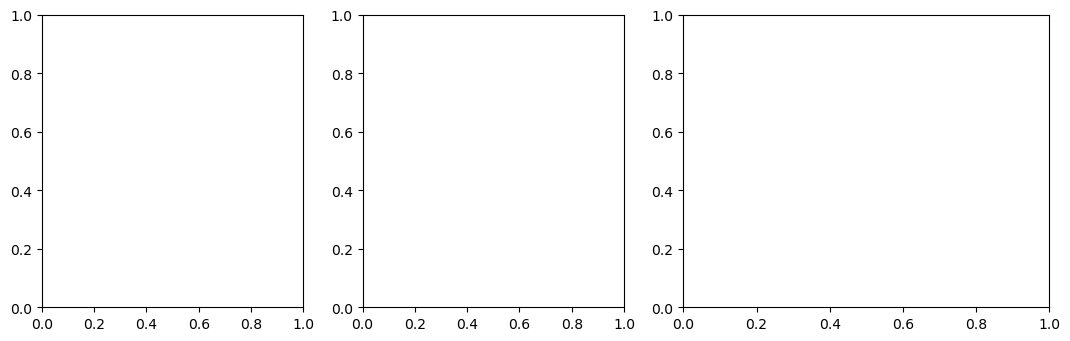

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8),
                         gridspec_kw={"width_ratios": [1, 1, 1.4]})

In [15]:
for ax, j in zip(axes[:2], (0, len(lags) - 1)):
    m = mats[j].astype(float)
    m /= m.max()
    im = ax.pcolormesh(log_ns, log_ns, m, cmap="viridis",
                       shading="auto", vmin=0, vmax=1)
    ax.set_title(f"lag {lags[j] * WINDOW_DT:.2f} s\n"
                 f"coupling D = {d[j]:.3f}")
    ax.set_xlabel(r"$\tau_2$ (ns)")
    ax.set_ylabel(r"$\tau_1$ (ns)")
    fig.colorbar(im, ax=ax, label="norm. counts")

In [16]:
axes[2].semilogx(lags * WINDOW_DT * 1e3, d, "o-", label="coupling D(dT)")
axes[2].axhline(baseline, ls=":", color="gray", label="noise floor")
axes[2].axvline(truth, color="tab:red", ls="--",
                label=f"true relaxation {truth:.1f} s")
axes[2].set_xlabel("lag dT (s)")
axes[2].set_ylabel("D (total variation)")
axes[2].set_title(f"fitted relaxation {recovered:.2f} s")
axes[2].legend()

In [17]:
fig.suptitle("2D-FDC of a simulated two-state emitter (1.5 / 3.5 ns, "
             "0.5 s$^{-1}$ exchange)", y=1.04)
fig.tight_layout()
plt.show()